# Notebook 12 — Comparativa final del zoológico (global v2)

Consolida resultados de los notebooks 04–11 sobre `tuvo_atraso`,
selecciona el modelo ganador, evalúa también `tuvo_sobrecosto` con la
configuración ganadora, y produce las visualizaciones de soporte.

**Inputs**: `data/resultados_modelos.json`, `data/modelos/*.pkl`
**Outputs**:
- `data/comparativa_modelos.csv`
- `data/metricas_test_ganador.csv`
- `figuras/12_comparativa_auc.png`
- `figuras/12_curvas_roc.png`
- `figuras/12_heatmap_metricas.png`
- `figuras/12_matriz_confusion_ganador.png`
- `data/modelos/GANADOR.txt`

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    roc_auc_score, f1_score, precision_score, recall_score, accuracy_score,
)
from xgboost import XGBClassifier
warnings.filterwarnings('ignore')

RAIZ = Path('..').resolve()
sys.path.insert(0, str(RAIZ))
from src.preprocesamiento import preparar, RANDOM_STATE

DATA = RAIZ / 'data'
FIGS = RAIZ / 'figuras'
MOD  = DATA / 'modelos'
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## 1. Cargar resultados consolidados

In [2]:
resultados = json.loads((DATA / 'resultados_modelos.json').read_text(encoding='utf-8'))
filas = []
for nombre, r in resultados.items():
    filas.append({
        'modelo':          nombre,
        'CV_AUC':          r['best_cv_auc'],
        'AUC_test':        r['AUC'],
        'F1':              r['F1'],
        'Precision':       r['Precision'],
        'Recall':          r['Recall'],
        'Accuracy':        r['Accuracy'],
        'tiempo_s':        r['tiempo_search_seg'],
        'n_iter':          r['n_iter'],
    })
tabla = pd.DataFrame(filas).sort_values('AUC_test', ascending=False).reset_index(drop=True)
tabla.to_csv(DATA / 'comparativa_modelos.csv', index=False, encoding='utf-8')
tabla

,modelo,CV_AUC,AUC_test,F1,Precision,Recall,Accuracy,tiempo_s,n_iter
0,lgbm,0.9094,0.9091,0.8503,0.8730,0.8288,0.8235,379.78,50
1,xgb,0.9085,0.9069,0.8500,0.8765,0.8250,0.8238,185.70,50
2,rf,0.8982,0.8996,0.8489,0.8262,0.8729,0.8120,367.97,40
3,mlp,0.8700,0.8630,0.8263,0.8147,0.8382,0.7868,86.23,20
4,lr,0.8424,0.8402,0.7982,0.8243,0.7737,0.7634,92.66,40
5,svm,0.8397,0.8381,0.8144,0.7705,0.8635,0.7619,222.67,15
6,knn,0.8258,0.8333,0.8077,0.7565,0.8663,0.7505,176.25,25
7,nb,0.7492,0.7519,0.3482,0.9952,0.2110,0.5222,7.79,20


## 2. Comparativa AUC test

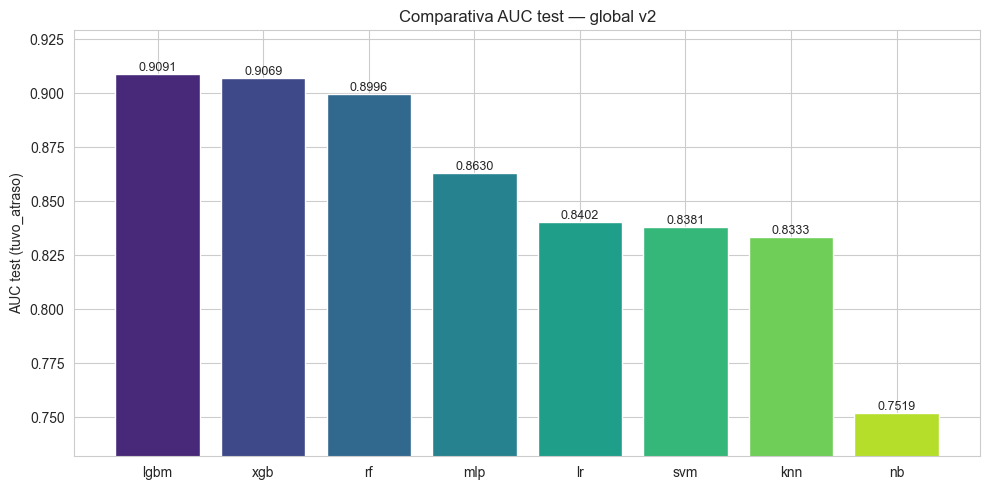

In [3]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tabla['modelo'], tabla['AUC_test'],
       color=sns.color_palette('viridis', n_colors=len(tabla)))
ax.set_ylim(tabla['AUC_test'].min() - 0.02, tabla['AUC_test'].max() + 0.02)
ax.set_ylabel('AUC test (tuvo_atraso)')
ax.set_title('Comparativa AUC test — global v2')
for i, v in enumerate(tabla['AUC_test']):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '12_comparativa_auc.png', dpi=120, bbox_inches='tight')
plt.show()

## 3. Curvas ROC

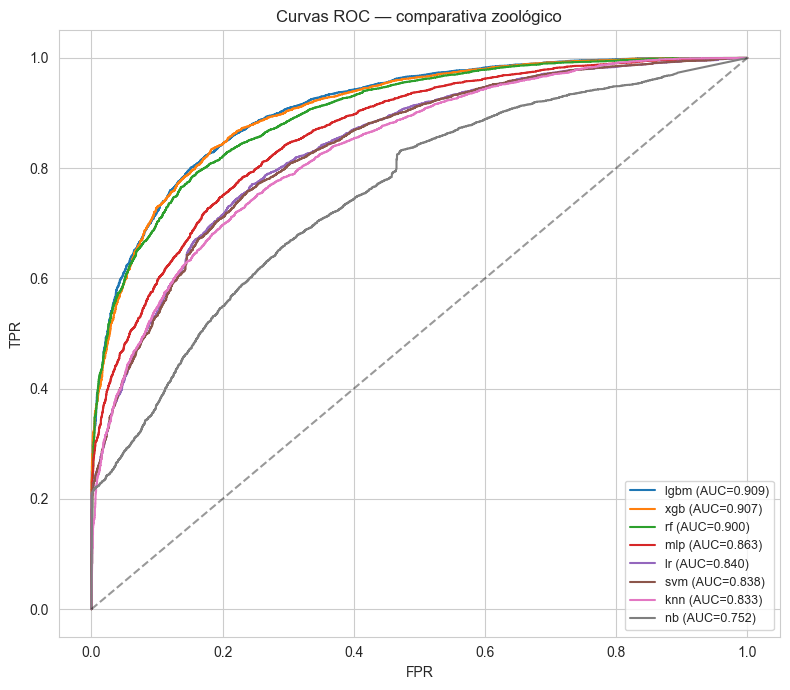

In [4]:
datos     = preparar(DATA, aplicar_escalado=False)
datos_esc = preparar(DATA, aplicar_escalado=True)
y_test    = datos.y_test['tuvo_atraso']

necesitan_escalado = {'lr','knn','svm','nb','mlp'}
fig, ax = plt.subplots(figsize=(8, 7))
for nombre in tabla['modelo']:
    mod = joblib.load(MOD / f'{nombre}.pkl')
    Xte = datos_esc.X_test if nombre in necesitan_escalado else datos.X_test
    if nombre == 'lgbm':
        Xte = Xte.copy(); Xte.columns = [__import__('re').sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in Xte.columns]
    if hasattr(mod, 'predict_proba'):
        s = mod.predict_proba(Xte)[:, 1]
    else:
        s = mod.decision_function(Xte)
        s = (s - s.min()) / (s.max() - s.min())
    fpr, tpr, _ = roc_curve(y_test, s)
    ax.plot(fpr, tpr, label=f'{nombre} (AUC={auc(fpr, tpr):.3f})')
ax.plot([0,1],[0,1],'k--',alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('Curvas ROC — comparativa zoológico')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(FIGS / '12_curvas_roc.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Heatmap métricas

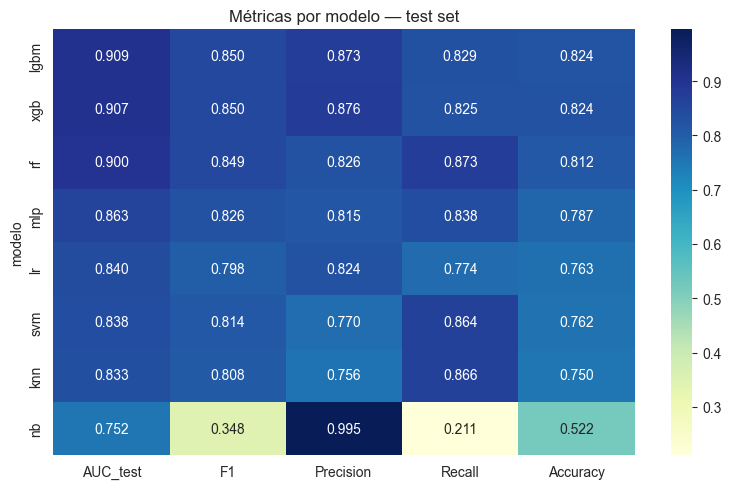

In [5]:
metr = ['AUC_test','F1','Precision','Recall','Accuracy']
hm = tabla.set_index('modelo')[metr]
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(hm, annot=True, fmt='.3f', cmap='YlGnBu', ax=ax)
ax.set_title('Métricas por modelo — test set')
plt.tight_layout()
plt.savefig(FIGS / '12_heatmap_metricas.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Selección del ganador

In [6]:
auc_top = tabla['AUC_test'].max()
cand = tabla[tabla['AUC_test'] >= auc_top - 0.003].copy()
gan_row = cand.sort_values(['F1','tiempo_s'], ascending=[False, True]).iloc[0]
ganador = gan_row['modelo']
(MOD / 'GANADOR.txt').write_text(
    f'ganador = {ganador}\nAUC_test = {gan_row["AUC_test"]}\nF1 = {gan_row["F1"]}\n',
    encoding='utf-8',
)
print(f'Ganador: {ganador.upper()}')
print(f'  AUC test = {gan_row["AUC_test"]}')
print(f'  F1       = {gan_row["F1"]}')
print(f'  Best params: {resultados[ganador]["best_params"]}')

Ganador: LGBM
  AUC test = 0.9091
  F1       = 0.8503
  Best params: {'colsample_bytree': 0.8159364365206693, 'learning_rate': 0.019950144748611585, 'max_depth': -1, 'min_child_samples': 50, 'n_estimators': 800, 'num_leaves': 127, 'subsample': 0.6644885149016018}


## 6. Matriz de confusión del ganador

Umbral 0,50 por defecto.

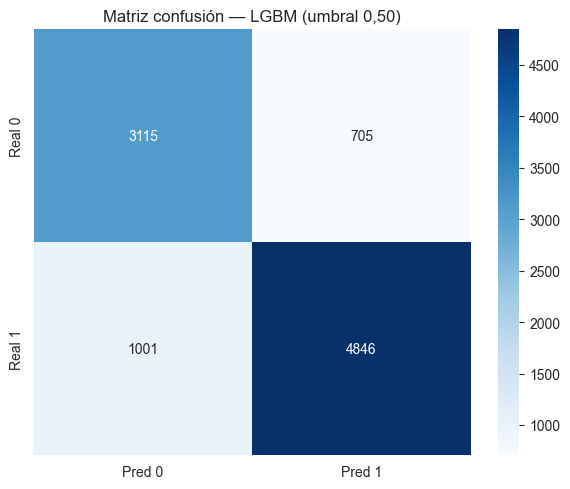

              precision    recall  f1-score   support

  sin_atraso       0.76      0.82      0.79      3820
  con_atraso       0.87      0.83      0.85      5847

    accuracy                           0.82      9667
   macro avg       0.81      0.82      0.82      9667
weighted avg       0.83      0.82      0.82      9667



In [7]:
mod_g = joblib.load(MOD / f'{ganador}.pkl')
Xte = datos_esc.X_test if ganador in necesitan_escalado else datos.X_test
if ganador == 'lgbm':
    Xte = Xte.copy(); Xte.columns = [__import__('re').sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in Xte.columns]
if hasattr(mod_g, 'predict_proba'):
    proba = mod_g.predict_proba(Xte)[:, 1]
else:
    proba = mod_g.decision_function(Xte)
    proba = (proba - proba.min()) / (proba.max() - proba.min())
pred = (proba >= 0.5).astype(int)
cm = confusion_matrix(y_test, pred)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['Real 0','Real 1'])
ax.set_title(f'Matriz confusión — {ganador.upper()} (umbral 0,50)')
plt.tight_layout()
plt.savefig(FIGS / '12_matriz_confusion_ganador.png', dpi=120, bbox_inches='tight')
plt.show()
print(classification_report(y_test, pred, target_names=['sin_atraso','con_atraso']))

## 7. Evaluación sobre `tuvo_sobrecosto`

Re-entrenar el algoritmo ganador con sus mejores HP pero target=sobrecosto.
Solo aplica si ganador es XGB o LGBM (boosting con `scale_pos_weight`).
Para árboles/lineales se reentrena con `class_weight='balanced'` si aplica.

In [8]:
best_params = resultados[ganador]['best_params']
y_train_sc = datos.y_train['tuvo_sobrecosto']
y_test_sc  = datos.y_test['tuvo_sobrecosto']
scale_pos_sc = (y_train_sc == 0).sum() / (y_train_sc == 1).sum()

if ganador in {'xgb','lgbm'}:
    if ganador == 'xgb':
        from xgboost import XGBClassifier
        clf = XGBClassifier(
            objective='binary:logistic', eval_metric='logloss',
            tree_method='hist', n_jobs=-1, random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_sc, **best_params,
        )
    else:
        from lightgbm import LGBMClassifier
        clf = LGBMClassifier(
            objective='binary', n_jobs=-1, random_state=RANDOM_STATE,
            scale_pos_weight=scale_pos_sc, verbose=-1, **best_params,
        )
    Xtr = datos.X_train
    Xtest = datos.X_test
elif ganador in {'rf'}:
    from sklearn.ensemble import RandomForestClassifier
    clf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    Xtr = datos.X_train
    Xtest = datos.X_test
else:
    # LR / MLP / KNN / SVM / NB — usar datos escalados
    from sklearn.linear_model import LogisticRegression
    from sklearn.neighbors import KNeighborsClassifier
    from sklearn.svm import LinearSVC
    from sklearn.calibration import CalibratedClassifierCV
    from sklearn.naive_bayes import GaussianNB
    from sklearn.neural_network import MLPClassifier
    if ganador == 'lr':
        clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1, **best_params)
    elif ganador == 'knn':
        clf = KNeighborsClassifier(n_jobs=-1, **best_params)
    elif ganador == 'svm':
        bp = {k.replace('estimator__',''): v for k,v in best_params.items()}
        clf = CalibratedClassifierCV(LinearSVC(max_iter=2000, random_state=RANDOM_STATE, dual='auto', **bp), method='sigmoid', cv=3)
    elif ganador == 'nb':
        clf = GaussianNB(**best_params)
    elif ganador == 'mlp':
        clf = MLPClassifier(max_iter=300, early_stopping=True, random_state=RANDOM_STATE, **best_params)
    Xtr   = datos_esc.X_train
    Xtest = datos_esc.X_test

if ganador == 'lgbm':
    Xtr = Xtr.copy(); Xtr.columns = [__import__('re').sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in Xtr.columns]
    Xtest = Xtest.copy(); Xtest.columns = [__import__('re').sub(r'[^A-Za-z0-9_]+', '_', str(c)) for c in Xtest.columns]
clf.fit(Xtr, y_train_sc)
if hasattr(clf, 'predict_proba'):
    p_sc = clf.predict_proba(Xtest)[:, 1]
else:
    p_sc = clf.decision_function(Xtest)
    p_sc = (p_sc - p_sc.min()) / (p_sc.max() - p_sc.min())
pr_sc = (p_sc >= 0.5).astype(int)

metr_sobrecosto = {
    'target':    'tuvo_sobrecosto',
    'AUC':       round(roc_auc_score(y_test_sc, p_sc), 4),
    'F1':        round(f1_score(y_test_sc, pr_sc), 4),
    'Precision': round(precision_score(y_test_sc, pr_sc), 4),
    'Recall':    round(recall_score(y_test_sc, pr_sc), 4),
    'Accuracy':  round(accuracy_score(y_test_sc, pr_sc), 4),
}
metr_atraso = {
    'target':    'tuvo_atraso',
    'AUC':       gan_row['AUC_test'],
    'F1':        gan_row['F1'],
    'Precision': gan_row['Precision'],
    'Recall':    gan_row['Recall'],
    'Accuracy':  gan_row['Accuracy'],
}
tabla_final = pd.DataFrame([metr_atraso, metr_sobrecosto])
tabla_final.to_csv(DATA / 'metricas_test_ganador.csv', index=False)
tabla_final

,target,AUC,F1,Precision,Recall,Accuracy
0,tuvo_atraso,0.9091,0.8503,0.8730,0.8288,0.8235
1,tuvo_sobrecosto,0.8338,0.8731,0.9105,0.8387,0.7978


## 8. Comparativa contra v1 (sprint padre)

In [9]:
# Referencias del sprint padre (XGB tuned FINAL)
REF_V1 = {
    'tuvo_atraso':     {'AUC': 0.9088, 'F1': 0.8522},
    'tuvo_sobrecosto': {'AUC': 0.8358, 'F1': 0.8508},
}
comp = pd.DataFrame([
    {'version': 'v1 (sprint padre XGB tuned)', 'target': 'atraso',
     'AUC': REF_V1['tuvo_atraso']['AUC'], 'F1': REF_V1['tuvo_atraso']['F1']},
    {'version': f'v2 ({ganador})', 'target': 'atraso',
     'AUC': metr_atraso['AUC'], 'F1': metr_atraso['F1']},
    {'version': 'v1 (sprint padre XGB tuned)', 'target': 'sobrecosto',
     'AUC': REF_V1['tuvo_sobrecosto']['AUC'], 'F1': REF_V1['tuvo_sobrecosto']['F1']},
    {'version': f'v2 ({ganador})', 'target': 'sobrecosto',
     'AUC': metr_sobrecosto['AUC'], 'F1': metr_sobrecosto['F1']},
])
comp['delta_AUC'] = comp.groupby('target')['AUC'].diff().fillna(0).round(4)
comp

,version,target,AUC,F1,delta_AUC
0,v1 (sprint padre XGB tuned),atraso,0.9088,0.8522,0.0000
1,v2 (lgbm),atraso,0.9091,0.8503,0.0003
2,v1 (sprint padre XGB tuned),sobrecosto,0.8358,0.8508,0.0000
3,v2 (lgbm),sobrecosto,0.8338,0.8731,-0.0020


In [10]:
resumen = {
    'n_modelos_evaluados': len(tabla),
    'ganador':             ganador,
    'AUC_atraso':          metr_atraso['AUC'],
    'F1_atraso':           metr_atraso['F1'],
    'AUC_sobrecosto':      metr_sobrecosto['AUC'],
    'F1_sobrecosto':       metr_sobrecosto['F1'],
    'mejor_params':        resultados[ganador]['best_params'],
}
(DATA / 'RESULTADO_FINAL.json').write_text(
    json.dumps(resumen, indent=2, ensure_ascii=False, default=str),
    encoding='utf-8',
)
print(json.dumps(resumen, indent=2, ensure_ascii=False, default=str))

{
  "n_modelos_evaluados": 8,
  "ganador": "lgbm",
  "AUC_atraso": 0.9091,
  "F1_atraso": 0.8503,
  "AUC_sobrecosto": 0.8338,
  "F1_sobrecosto": 0.8731,
  "mejor_params": {
    "colsample_bytree": 0.8159364365206693,
    "learning_rate": 0.019950144748611585,
    "max_depth": -1,
    "min_child_samples": 50,
    "n_estimators": 800,
    "num_leaves": 127,
    "subsample": 0.6644885149016018
  }
}
